In [70]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv', sep=';')

In [7]:
#Conocimiento del dataset
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
#Conocimiento del dataset
df.shape

(41188, 21)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [10]:
#Mirar si hay duplicados
duplicados = df.duplicated()
num_duplicados = duplicados.sum()
print(f'hay {num_duplicados} filas duplicadas')

hay 12 filas duplicadas


In [11]:
duplicats_copies = df[df.duplicated()]
print(duplicats_copies)

       age          job   marital            education  default housing loan  \
1266    39  blue-collar   married             basic.6y       no      no   no   
12261   36      retired   married              unknown       no      no   no   
14234   27   technician    single  professional.course       no      no   no   
16956   47   technician  divorced          high.school       no     yes   no   
18465   32   technician    single  professional.course       no     yes   no   
20216   55     services   married          high.school  unknown      no   no   
20534   41   technician   married  professional.course       no     yes   no   
25217   39       admin.   married    university.degree       no      no   no   
28477   24     services    single          high.school       no     yes   no   
32516   35       admin.   married    university.degree       no     yes   no   
36951   45       admin.   married    university.degree       no      no   no   
38281   71      retired    single    uni

In [12]:
df = df.drop_duplicates()
df.shape

(41176, 21)

Dado el gran volumen de datos disponible se decide eliminar los duplicados, obviando la posibildad de que existan dos clientes con los mismos valores en todos los atributos.

## Selección de Atriutos relevantes
De momento solo se elimina duración, sabiendo que, en el futuro, no estará disponible hasta después de la llamada

In [13]:
df.drop(["duration"], axis = 1, inplace = True)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [14]:
#valores faltantes
df.isnull().sum().sort_values(ascending=False)

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


### Análisis univariante

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  campaign        41176 non-null  int64  
 11  pdays           41176 non-null  int64  
 12  previous        41176 non-null  int64  
 13  poutcome        41176 non-null  object 
 14  emp.var.rate    41176 non-null  float64
 15  cons.price.idx  41176 non-null  float64
 16  cons.conf.idx   41176 non-null  float64
 17  euribor3m       41176 non-null  floa

#### Análisis variables categóricas

In [16]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(f"=== {col.upper()} ===")
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    for category in counts.index:
        print(f"{category}: {counts[category]} ({percentages[category]:.1f}%)")

=== JOB ===
admin.: 10419 (25.3%)
blue-collar: 9253 (22.5%)
technician: 6739 (16.4%)
services: 3967 (9.6%)
management: 2924 (7.1%)
retired: 1718 (4.2%)
entrepreneur: 1456 (3.5%)
self-employed: 1421 (3.5%)
housemaid: 1060 (2.6%)
unemployed: 1014 (2.5%)
student: 875 (2.1%)
unknown: 330 (0.8%)
=== MARITAL ===
married: 24921 (60.5%)
single: 11564 (28.1%)
divorced: 4611 (11.2%)
unknown: 80 (0.2%)
=== EDUCATION ===
university.degree: 12164 (29.5%)
high.school: 9512 (23.1%)
basic.9y: 6045 (14.7%)
professional.course: 5240 (12.7%)
basic.4y: 4176 (10.1%)
basic.6y: 2291 (5.6%)
unknown: 1730 (4.2%)
illiterate: 18 (0.0%)
=== DEFAULT ===
no: 32577 (79.1%)
unknown: 8596 (20.9%)
yes: 3 (0.0%)
=== HOUSING ===
yes: 21571 (52.4%)
no: 18615 (45.2%)
unknown: 990 (2.4%)
=== LOAN ===
no: 33938 (82.4%)
yes: 6248 (15.2%)
unknown: 990 (2.4%)
=== CONTACT ===
cellular: 26135 (63.5%)
telephone: 15041 (36.5%)
=== MONTH ===
may: 13767 (33.4%)
jul: 7169 (17.4%)
aug: 6176 (15.0%)
jun: 5318 (12.9%)
nov: 4100 (10.0%)
a

In [17]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


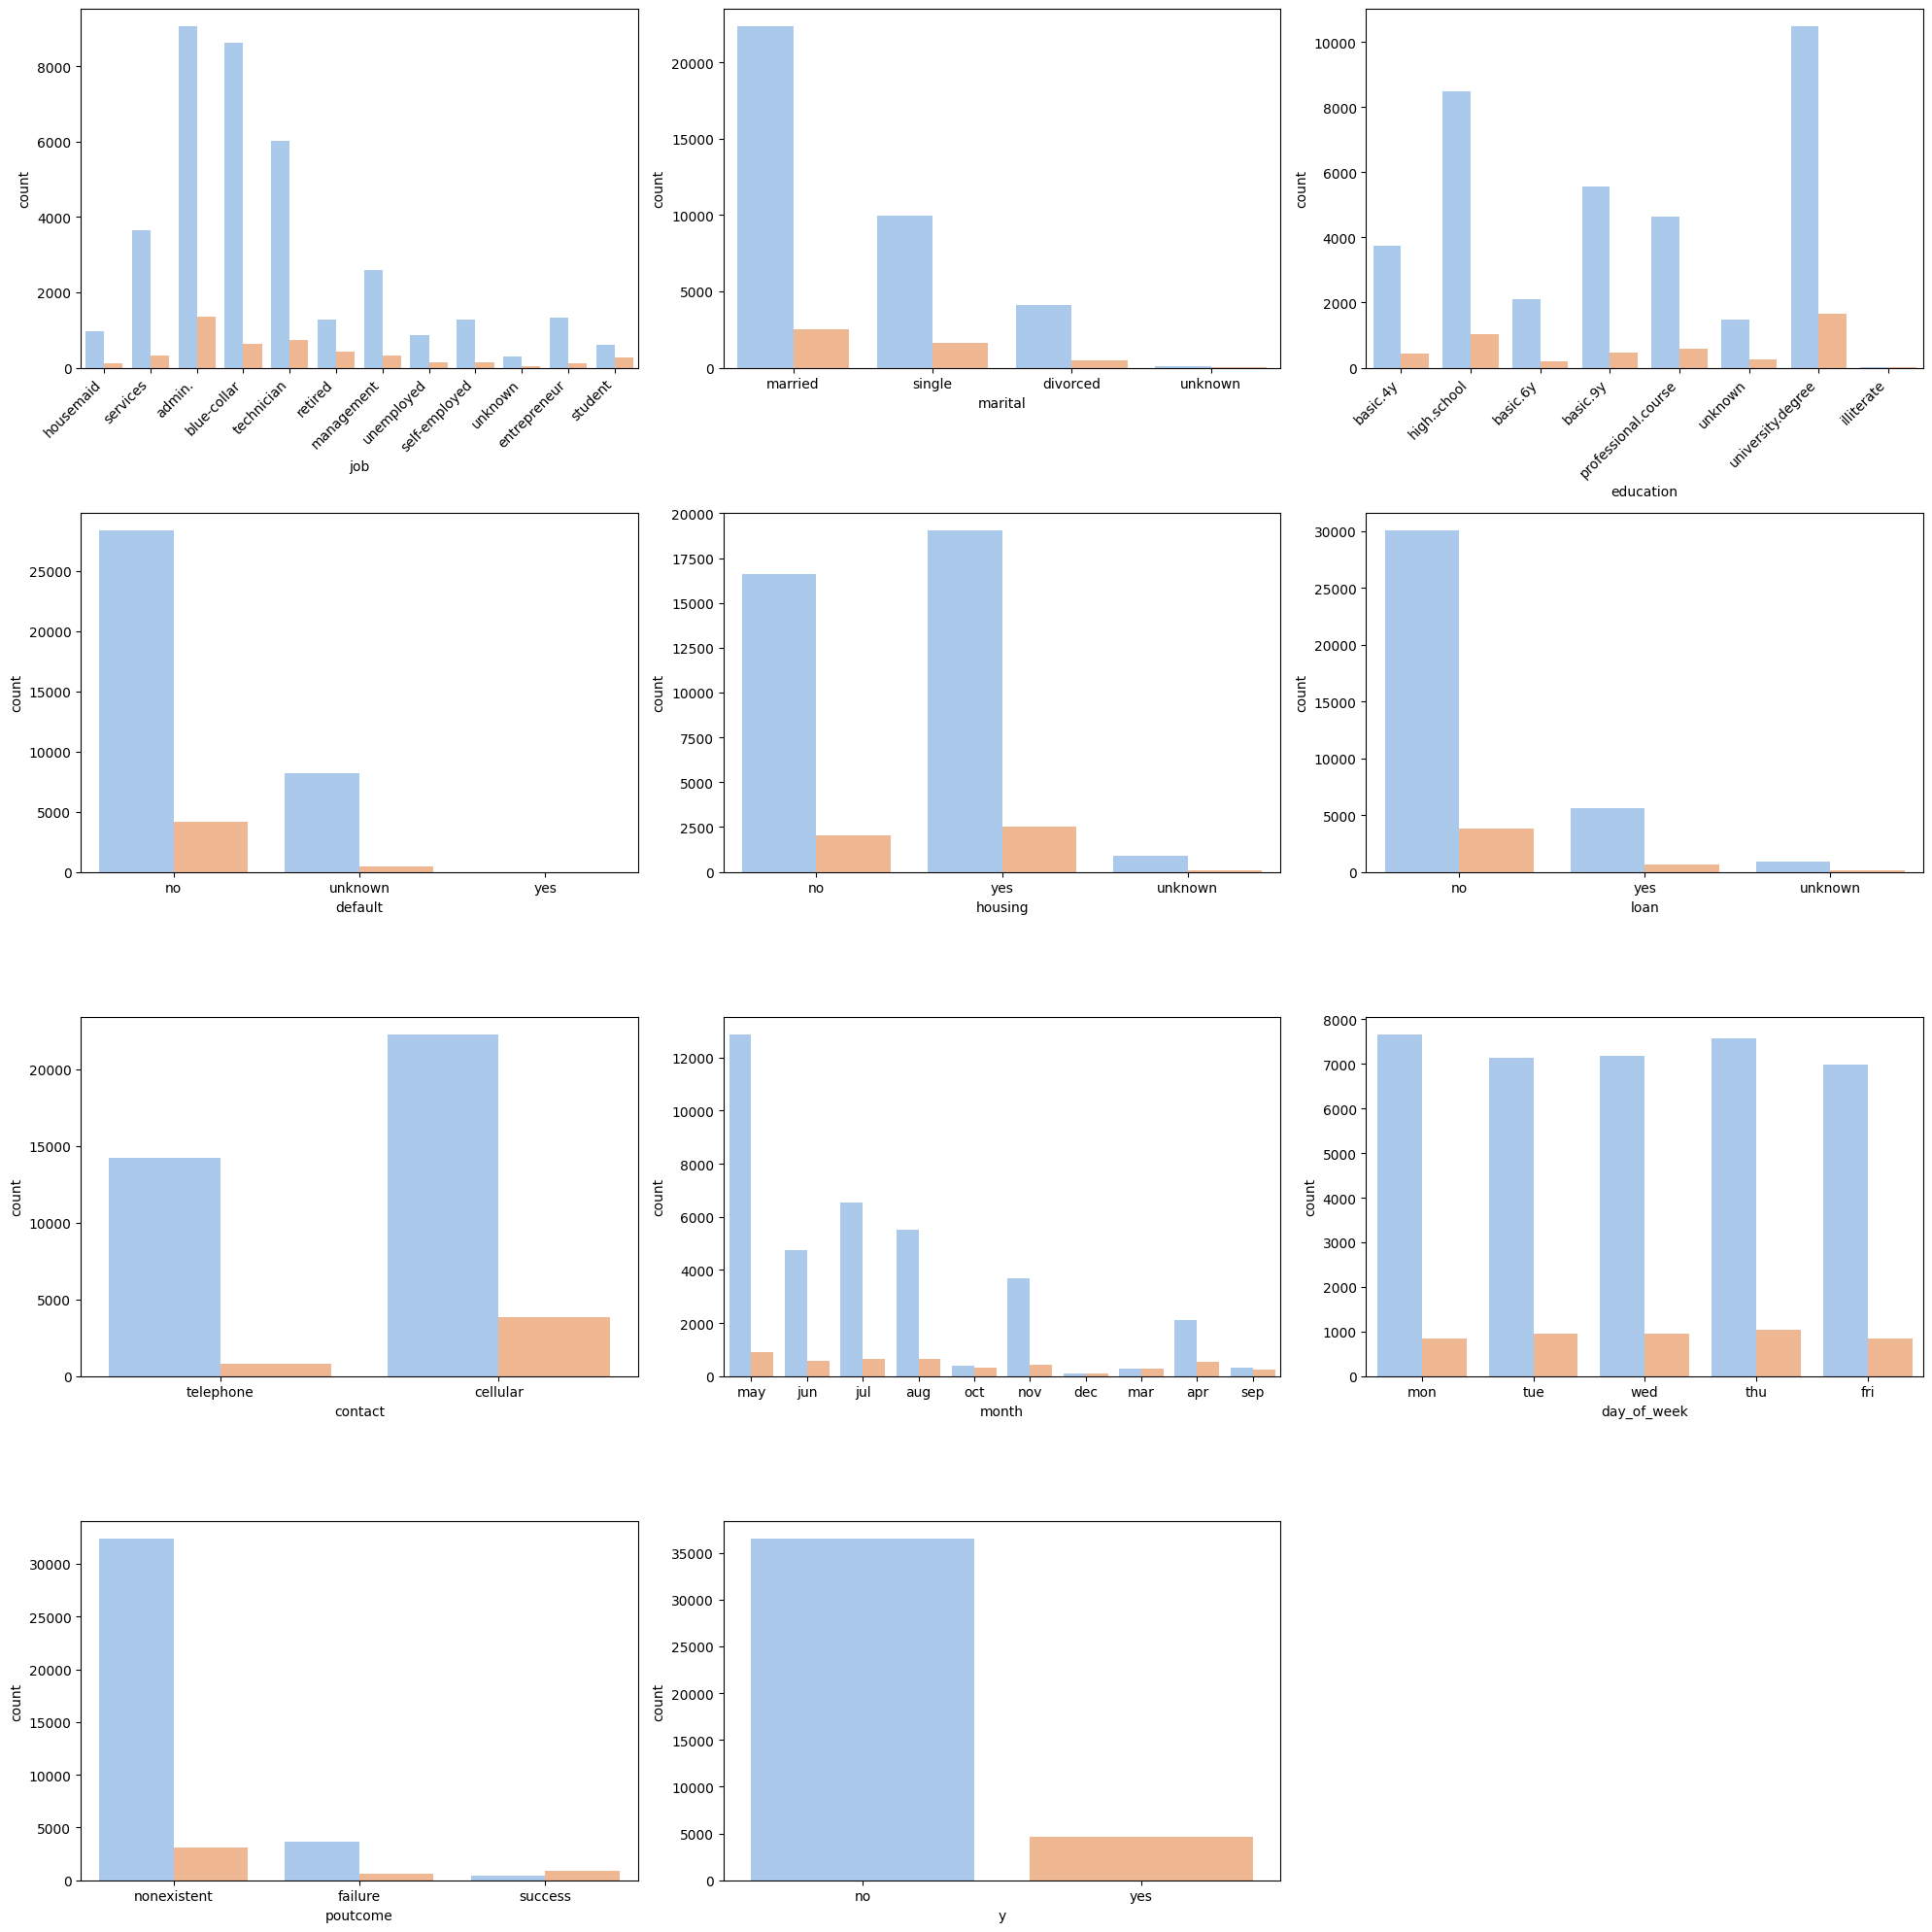

In [18]:
fig, axis = plt.subplots(4, 3, figsize = (20, 20))

sns.countplot(ax = axis[0, 0], data = df, x = "job", palette='pastel', hue= "y", legend=False)
axis[0, 0].set_xticklabels(axis[0, 0].get_xticklabels(), rotation=45, ha='right')
sns.countplot(ax = axis[0, 1], data = df, x = "marital", palette='pastel', hue= "y", legend=False)
sns.countplot(ax = axis[0, 2], data = df, x = "education", palette='pastel', hue= "y", legend=False)
axis[0, 2].set_xticklabels(axis[0, 2].get_xticklabels(), rotation=45, ha='right')
sns.countplot(ax = axis[1, 0], data = df, x = "default", palette='pastel', hue= "y", legend=False)
sns.countplot(ax = axis[1, 1], data = df, x = "housing", palette='pastel', hue= "y", legend=False)
sns.countplot(ax = axis[1, 2], data = df, x = "loan", palette='pastel', hue= "y", legend=False)
sns.countplot(ax = axis[2, 0], data = df, x = "contact", palette='pastel', hue= "y", legend=False)
sns.countplot(ax = axis[2, 1], data = df, x = "month", palette='pastel', hue= "y", legend=False)
sns.countplot(ax = axis[2, 2], data = df, x = "day_of_week", palette='pastel', hue= "y", legend=False)
sns.countplot(ax = axis[3, 0], data = df, x = "poutcome", palette='pastel', hue= "y", legend=False)
sns.countplot(ax = axis[3, 1], data = df, x = "y", palette='pastel', hue= "y", legend=False)

fig.delaxes(axis[3,2])

plt.tight_layout()
plt.show()


In [19]:
categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

Con la representación de estas variables podemos deducir que:

job:
- Distribución diversa con tres grupos principales que representan el 64.2% del total
- Segmento prometedor: Retired (4.2%) - posible alta propensión al ahorro
- Segmento crítico: Student (2.1%) - baja capacidad de ahorro
- Oportunidad: Focus en admin, blue-collar y technician que representan el 64.2% de la base

marital:
- Clientes mayormente casados (60.5%) - posible mayor estabilidad financiera
- Solteros representan 28.1% - posiblemente menor compromiso financiero
- Datos muy completos - solo 0.2% desconocidos

education:
- Alto nivel educativo: 29.5% con grado universitario
- Base sólida: 52.6% tienen educación media/alta (high_school + university)
- Problema de datos: 4.2% desconocidos - requiere tratamiento

default:
- Variable prácticamente inútil para predicción.
- Solo 3 casos de impagos - sin poder predictivo
- 20.9% desconocidos - problema de calidad de datos
- Requiere tratamiento - posible eliminación del modelo predictivo

housing:
- Ligera mayoría con hipoteca (52.4%)
- Segmento significativo sin hipoteca (45.2%) - posible mayor capacidad de ahorro
- Buenos datos - solo 2.4% desconocidos

loan:
- 82.4% sin préstamos personales
- Alta capacidad de ahorro potencial en la mayoría de clientes
- Segmento claro: Enfocar en clientes sin deudas personales

contact:
- Tendencia: 63.5% contactados vía móvil
- Doble canal: Uso combinado de móvil y fijo

month:
- 33.4% de contactos concentrados en MAYO
- Estacionalidad marcada: 78.7% entre mayo-agosto
- Meses desaprovechados: oct, sep, mar, dec con menos del 2% cada uno

day_of_week:
- Distribución perfecta entre días laborables, contacto distribuido equitativamente
- Estrategia consistente: No hay preferencia por ningún día específico

poutcome:
- 86.3% sin historial previo - difícil aprendizaje
- Baja tasa de éxito histórico: Solo 3.3% de conversiones pasadas
- El modelo deberá basarse más en características demográficas que en historial

y:
- Desbalance extremo: Relación 9:1 entre no/sí
- Tasa de conversión baja: 11.3% - típico en marketing bancario
- Impacto en modelo: Necesidad de técnicas especiales para desbalance
- Reto predictivo: Difícil identificar patrones en minoría positiva

#### CONCLUSIONES ESTRATÉGICAS

PROBLEMAS CRÍTICOS:
- Desbalance extremo en target (11.3% conversión)
- Concentración temporal (33.4% contactos en mayo)
- Falta de historial (86.3% sin datos previos)
- Variables inútiles (default con solo 3 casos positivos)

OPORTUNIDADES:
- Segmento premium: Casados sin préstamos (60.5% married + 82.4% no loan)
- Clientes educados: 29.5% con grado universitario
- Base estable: Ocupaciones diversificadas y estables
- Doble canal de contacto: Móvil (63.5%) y fijo (36.5%)

RECOMENDACIONES PARA EL BANCO:
- Diversificar calendario de contactos



In [20]:
#Eliminar default del datset
df.drop(["default"], axis = 1, inplace = True)
df.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [21]:
#Tratar los clientes sin hsitorial en poutcome
df['cliente_nuevo'] = (df['poutcome'] == 'nonexistent').astype(int)

# Variables adicionales para mantener el historial existente
df['historial_previo_exitoso'] = (df['poutcome'] == 'success').astype(int)
df['historial_previo_fallo'] = (df['poutcome'] == 'failure').astype(int)

# Eliminar la variable original
df = df.drop('poutcome', axis=1)
df.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,...,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,cliente_nuevo,historial_previo_exitoso,historial_previo_fallo
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,1,...,0,1.1,93.994,-36.4,4.857,5191.0,no,1,0,0
1,57,services,married,high.school,no,no,telephone,may,mon,1,...,0,1.1,93.994,-36.4,4.857,5191.0,no,1,0,0
2,37,services,married,high.school,yes,no,telephone,may,mon,1,...,0,1.1,93.994,-36.4,4.857,5191.0,no,1,0,0
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,1,...,0,1.1,93.994,-36.4,4.857,5191.0,no,1,0,0
4,56,services,married,high.school,no,yes,telephone,may,mon,1,...,0,1.1,93.994,-36.4,4.857,5191.0,no,1,0,0


Con esto se consiguen 3 nuevas variables, con la intención de usar cliente_nuevo en el modelo que es la más representativa en los datos y apoyarse con el resto de variables.

In [22]:
# Agrupar eduacation
print(df['education'].value_counts())

education
university.degree      12164
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
unknown                 1730
illiterate                18
Name: count, dtype: int64


In [23]:
unknown_analysis = df[df['education'] == 'unknown'].groupby('job').size()
print(unknown_analysis)

job
admin.           249
blue-collar      454
entrepreneur      57
housemaid         42
management       123
retired           97
self-employed     29
services         150
student          167
technician       212
unemployed        19
unknown          131
dtype: int64


Se mantienen los unknown como categoria porque no hay patrones claros.

In [24]:
def agrupar_education(edu_valor):
    if edu_valor.startswith('basic.'):
        return 'basic'
    elif edu_valor in ['university.degree', 'professional.course']:
        return 'higher_education'
    elif edu_valor == 'high.school':
        return 'high_school'
    elif edu_valor == 'unknown':
        return 'unknown'
    elif edu_valor == 'illiterate':
        return 'no_education'  # ← Nueva categoría
    else:
        return edu_valor

df['education_grouped'] = df['education'].apply(agrupar_education)
df = df.drop('education', axis=1)  # Eliminar original

In [25]:
#Verificación
print("=== EDUCATION AGRUPADA ===")
print(df['education_grouped'].value_counts())

=== EDUCATION AGRUPADA ===
education_grouped
higher_education    17404
basic               12512
high_school          9512
unknown              1730
no_education           18
Name: count, dtype: int64


In [26]:
#Agrupar meses en estaciones
conditions = [
    df['month'].isin(['mar', 'apr', 'may']),
    df['month'].isin(['jun', 'jul', 'aug']),
    df['month'].isin(['sep', 'oct', 'nov']),
    df['month'].isin(['dec', 'jan', 'feb'])
]

choices = ['primavera', 'verano', 'otono', 'invierno']

df['season'] = np.select(conditions, choices, default='desconocido')
df = df.drop('month', axis=1)  # Eliminar original

In [27]:
df.head()

,age,job,marital,housing,loan,contact,day_of_week,campaign,pdays,previous,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,cliente_nuevo,historial_previo_exitoso,historial_previo_fallo,education_grouped,season
0,56,housemaid,married,no,no,telephone,mon,1,999,0,...,93.994,-36.4,4.857,5191.0,no,1,0,0,basic,primavera
1,57,services,married,no,no,telephone,mon,1,999,0,...,93.994,-36.4,4.857,5191.0,no,1,0,0,high_school,primavera
2,37,services,married,yes,no,telephone,mon,1,999,0,...,93.994,-36.4,4.857,5191.0,no,1,0,0,high_school,primavera
3,40,admin.,married,no,no,telephone,mon,1,999,0,...,93.994,-36.4,4.857,5191.0,no,1,0,0,basic,primavera
4,56,services,married,no,yes,telephone,mon,1,999,0,...,93.994,-36.4,4.857,5191.0,no,1,0,0,high_school,primavera


In [28]:
#Combinar housing y loan para calcular nivel de endeudamiento
df['debt_burden'] = 'ninguno'

# Casos conocidos (ambas variables conocidas)
df.loc[(df['housing'] == 'yes') & (df['loan'] == 'no'), 'debt_burden'] = 'solo_hipoteca'
df.loc[(df['housing'] == 'no') & (df['loan'] == 'yes'), 'debt_burden'] = 'solo_prestamo'
df.loc[(df['housing'] == 'yes') & (df['loan'] == 'yes'), 'debt_burden'] = 'ambos'

# Casos parcialmente desconocidos
df.loc[(df['housing'] == 'yes') & (df['loan'] == 'unknown'), 'debt_burden'] = 'probable_hipoteca'
df.loc[(df['housing'] == 'no') & (df['loan'] == 'unknown'), 'debt_burden'] = 'probable_ninguno'
df.loc[(df['housing'] == 'unknown') & (df['loan'] == 'yes'), 'debt_burden'] = 'probable_prestamo'
df.loc[(df['housing'] == 'unknown') & (df['loan'] == 'no'), 'debt_burden'] = 'probable_ninguno'

# Solo completamente desconocidos
df.loc[(df['housing'] == 'unknown') & (df['loan'] == 'unknown'), 'debt_burden'] = 'completamente_desconocido'

# Verificar que TODAS las filas tienen una categoría asignada
categorias_validas = ['ninguno', 'solo_hipoteca', 'solo_prestamo', 'ambos',
                     'probable_hipoteca', 'probable_ninguno', 'probable_prestamo',
                     'completamente_desconocido']

casos_sin_clasificar = ~df['debt_burden'].isin(categorias_validas)
print(f"Casos sin clasificar: {casos_sin_clasificar.sum()}")

Casos sin clasificar: 0


- probable_hipoteca: Si sabemos que tiene hipoteca, asumimos que no tiene préstamo
- probable_ninguno: Si sabemos que no tiene una deuda, asumimos que no tiene la otra
- probable_prestamo: Si sabemos que tiene préstamo, asumimos que no tiene hipoteca

In [29]:
#2a Verificación para saber si debt_burden añade valor predictivo
df['y_numeric'], categories = pd.factorize(df['y'])
print(f"Mapeo: {categories}")

# Cruzar con el target para ver patrones
print("\n=== TASA DE CONVERSIÓN POR DEBT_BURDEN ===")
conversion_por_debt = df.groupby('debt_burden')['y_numeric'].mean().sort_values(ascending=False)
print((conversion_por_debt * 100).round(1))

Mapeo: Index(['no', 'yes'], dtype='object')

=== TASA DE CONVERSIÓN POR DEBT_BURDEN ===
debt_burden
solo_hipoteca                11.7
ambos                        11.1
ninguno                      10.9
completamente_desconocido    10.8
solo_prestamo                10.7
Name: y_numeric, dtype: float64


- Debt_burden SÍ es predictiva - hay diferencias de conversión entre categorías. Será útil para el modelo.
- Se encuentra un patrón inesperado donde los clientes con solo hipoteca son 9% más propensos a contratar que los con solo préstamo.
- Se decide mantener las columnas de loan y housing, porque dan transparencia en los datos y aún pueden tener valor predictivo para el modelo.


### Anáisis variables numéricas

In [30]:
#Conocimiento variables numéricas del dataset
df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,cliente_nuevo,historial_previo_exitoso,historial_previo_fallo,y_numeric
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870,0.863391,0.033345,0.103264,0.112663
std,10.42068,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364,0.343438,0.179537,0.304307,0.316184
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000,0.000000,0.000000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,1.000000,0.000000,0.000000,0.000000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,1.000000,0.000000,0.000000,0.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,1.000000,0.000000,0.000000,0.000000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,1.000000,1.000000,1.000000


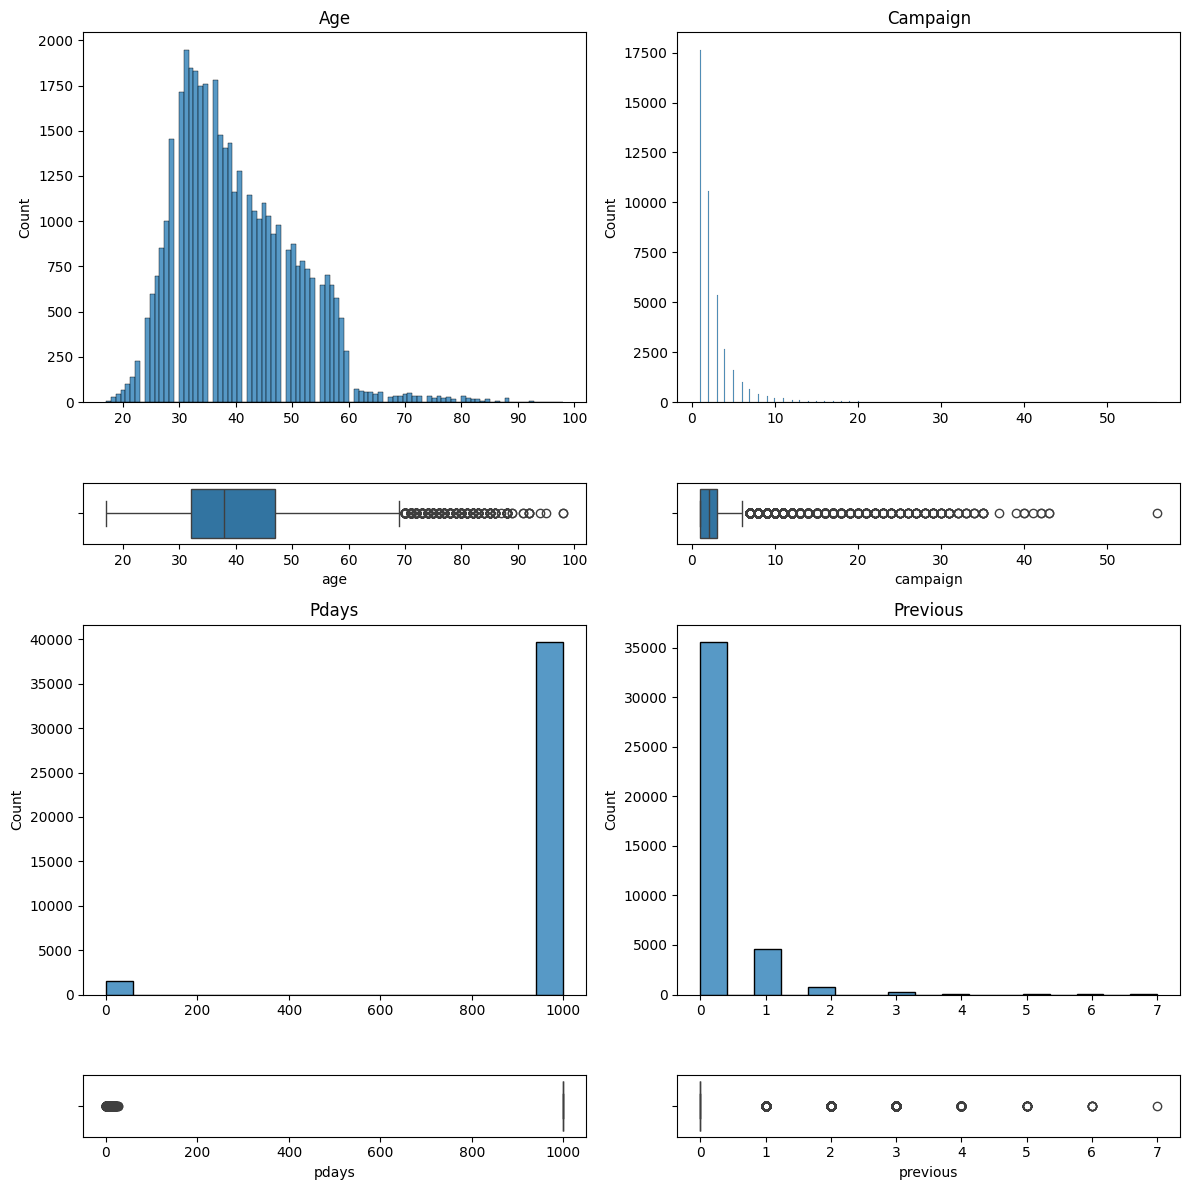

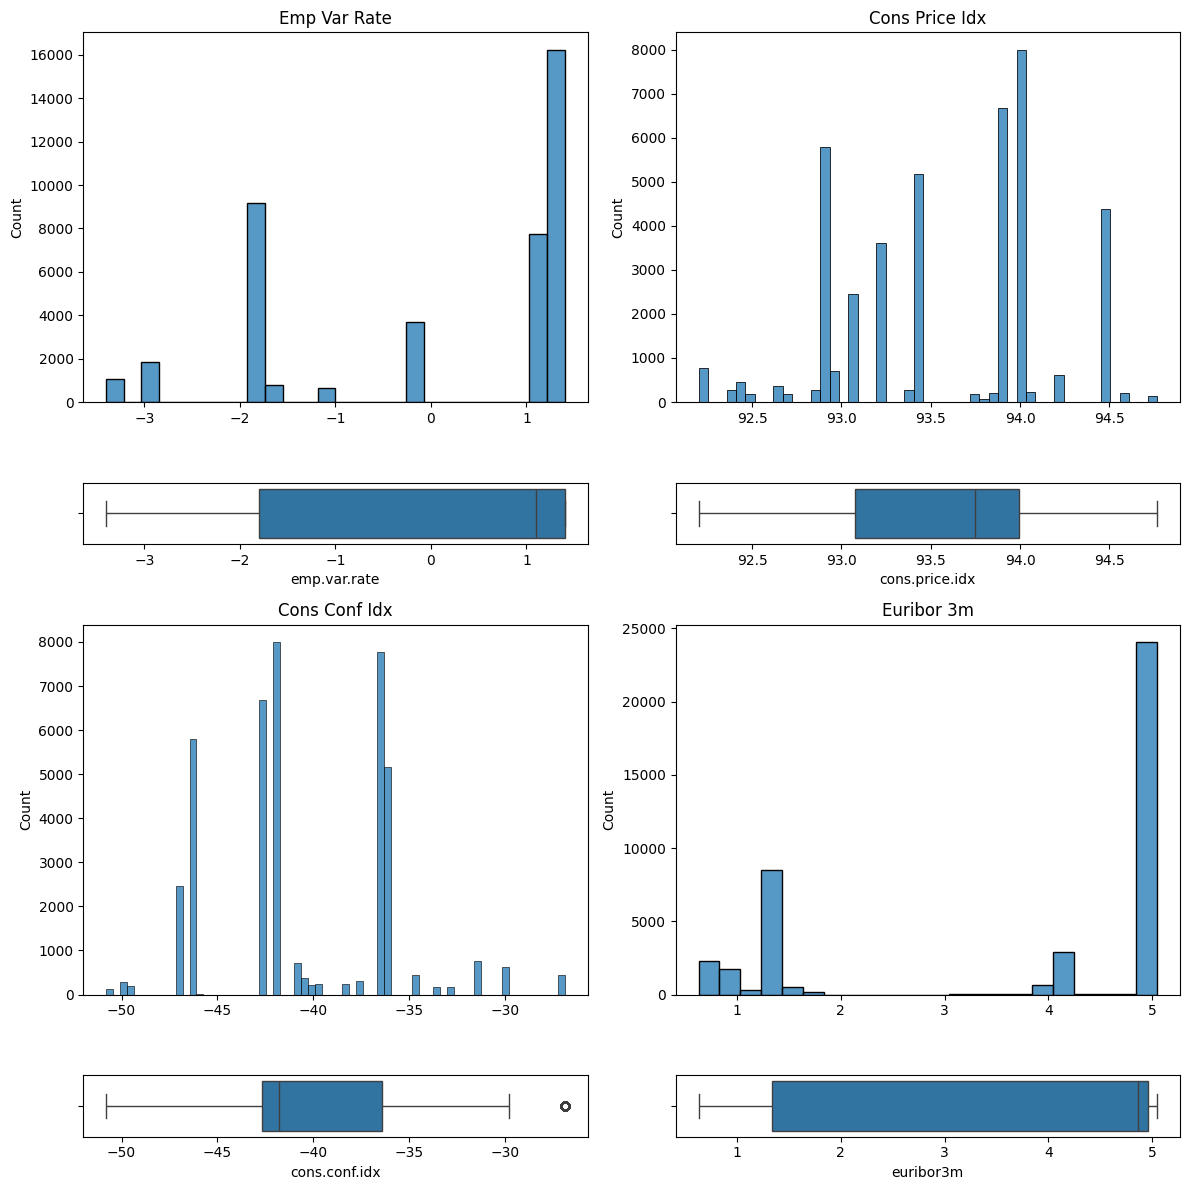

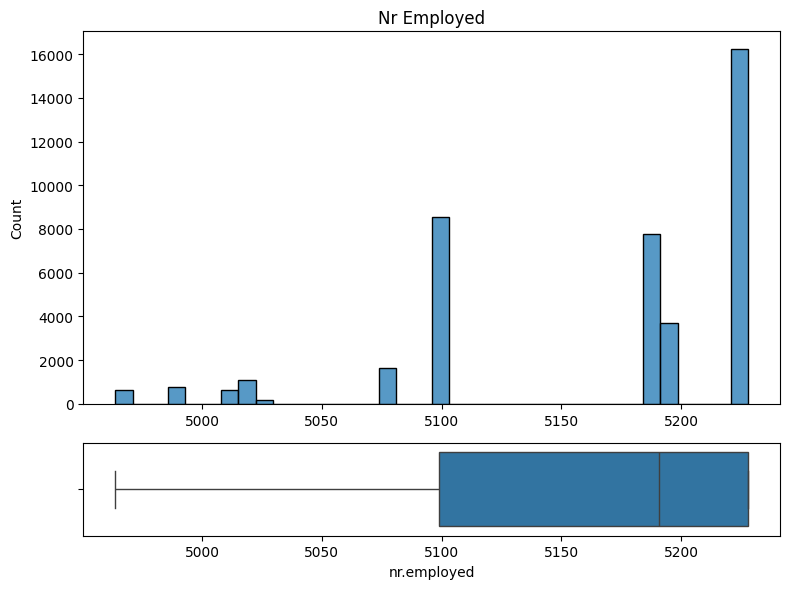

In [31]:
# En grupos de 4 variables
fig, axes = plt.subplots(4, 2, figsize=(12, 12), gridspec_kw={'height_ratios': [6, 1, 6, 1]})

# Primeras 4 variables
sns.histplot(ax=axes[0, 0], data=df, x="age").set(xlabel=None, title="Age")
sns.boxplot(ax=axes[1, 0], data=df, x="age")

sns.histplot(ax=axes[0, 1], data=df, x="campaign").set(xlabel=None, title="Campaign")
sns.boxplot(ax=axes[1, 1], data=df, x="campaign")

sns.histplot(ax=axes[2, 0], data=df, x="pdays").set(xlabel=None, title="Pdays")
sns.boxplot(ax=axes[3, 0], data=df, x="pdays")

sns.histplot(ax=axes[2, 1], data=df, x="previous").set(xlabel=None, title="Previous")
sns.boxplot(ax=axes[3, 1], data=df, x="previous")

plt.tight_layout()
plt.show()

# Siguientes 4 variables
fig, axes = plt.subplots(4, 2, figsize=(12, 12), gridspec_kw={'height_ratios': [6, 1, 6, 1]})

sns.histplot(ax=axes[0, 0], data=df, x="emp.var.rate").set(xlabel=None, title="Emp Var Rate")
sns.boxplot(ax=axes[1, 0], data=df, x="emp.var.rate")

sns.histplot(ax=axes[0, 1], data=df, x="cons.price.idx").set(xlabel=None, title="Cons Price Idx")
sns.boxplot(ax=axes[1, 1], data=df, x="cons.price.idx")

sns.histplot(ax=axes[2, 0], data=df, x="cons.conf.idx").set(xlabel=None, title="Cons Conf Idx")
sns.boxplot(ax=axes[3, 0], data=df, x="cons.conf.idx")

sns.histplot(ax=axes[2, 1], data=df, x="euribor3m").set(xlabel=None, title="Euribor 3m")
sns.boxplot(ax=axes[3, 1], data=df, x="euribor3m")

plt.tight_layout()
plt.show()

# Última variable
fig, axes = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [4, 1]})
sns.histplot(ax=axes[0], data=df, x="nr.employed").set(xlabel=None, title="Nr Employed")
sns.boxplot(ax=axes[1], data=df, x="nr.employed")
plt.tight_layout()
plt.show()

De los gráficos obtenidos:
Nos fijamos en la distribución de los datos. A primera vista se decide:
- Filtrar campaign por debajo de 20, porque más podría ser un error o algun fallo que da como resultado el acoso extremo.
- Mantener el outlier de cons.conf.idx ya que sigue estando dentro del rango normal de valores para este índice.

In [32]:
#Guardar el tamaño original del dataset
filas_originales = len(df)
print(f"Filas antes de filtrar: {filas_originales}")

# Aplicar filtro de campaign
df = df[(df['campaign'] <= 20)]

# Mostrar resultados
filas_finales = len(df)
print(f"Filas después de filtrar: {filas_finales}")

Filas antes de filtrar: 41176
Filas después de filtrar: 41019


In [33]:
#Tratamiento pdays
pdays_percent = df['pdays'].value_counts(normalize=True) * 100
print(pdays_percent.head(20))

pdays
999    96.306590
3       1.070236
6       1.004413
4       0.287672
9       0.156025
2       0.148712
7       0.146274
12      0.141398
10      0.126771
5       0.112143
13      0.087764
11      0.068261
1       0.063385
15      0.058509
14      0.048758
8       0.043882
0       0.036568
16      0.026817
17      0.019503
18      0.017065
Name: proportion, dtype: float64


In [34]:
#Convertir pdays a binaria
df['sin_registro'] = (df['pdays'] == 999).astype(int)

#Ver si es predictiva
print("Tasa conversión clientes nuevos vs recurrentes:")
print(df.groupby('sin_registro')['y_numeric'].mean() * 100)

Tasa conversión clientes nuevos vs recurrentes:
sin_registro
0    63.828383
1     9.292730
Name: y_numeric, dtype: float64


In [35]:
# Verificar exactamente qué significa 0 y 1
print("=== VERIFICACIÓN DEL MAPEO ===")
print(df.groupby('pdays')['sin_registro'].first().head())

# O más claro:
print("\n=== QUÉ SIGNIFICA CADA VALOR ===")
print("Clientes con pdays = 999:")
print(f"  sin_registro = {df[df['pdays'] == 999]['sin_registro'].iloc[0]}")

print("Clientes con pdays ≠ 999:")
print(f"  sin_registro = {df[df['pdays'] != 999]['sin_registro'].iloc[0]}")

=== VERIFICACIÓN DEL MAPEO ===
pdays
0    0
1    0
2    0
3    0
4    0
Name: sin_registro, dtype: int64

=== QUÉ SIGNIFICA CADA VALOR ===
Clientes con pdays = 999:
  sin_registro = 1
Clientes con pdays ≠ 999:
  sin_registro = 0


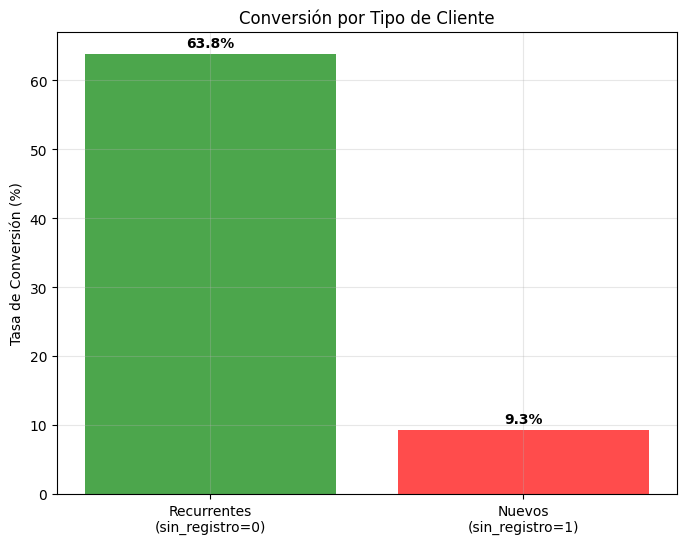

Los clientes recurrentes son 6.9x más propensos a contratar


In [36]:
#Conversión
conversion_data = df.groupby('sin_registro')['y_numeric'].mean() * 100
categorias = ['Recurrentes\n(sin_registro=0)', 'Nuevos\n(sin_registro=1)']

#Gráfico
plt.figure(figsize=(8, 6))
bars = plt.bar(categorias, conversion_data, color=['green', 'red'], alpha=0.7)

#Añadir valores en las barras
for bar, valor in zip(bars, conversion_data):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{valor:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Tasa de Conversión (%)')
plt.title('Conversión por Tipo de Cliente')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Los clientes recurrentes son {conversion_data[0]/conversion_data[1]:.1f}x más propensos a contratar")

In [37]:
df.drop(["pdays"], axis = 1, inplace = True)

pdays tenía 96% de valores iguales (999), lo que la hacía poco útil como variable numérica. Al transformarla en sin_registro (binaria) se puede ver que los clientes recurrentes tienen 7 veces más probabilidad de contratar, creando una variable mucho más predictiva e interpretable.

Por lo que decido eliminar pdays del dataset.

### Análisis multivariante
#### Análisis numérico-numérico

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41019 entries, 0 to 41187
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       41019 non-null  int64  
 1   job                       41019 non-null  object 
 2   marital                   41019 non-null  object 
 3   housing                   41019 non-null  object 
 4   loan                      41019 non-null  object 
 5   contact                   41019 non-null  object 
 6   day_of_week               41019 non-null  object 
 7   campaign                  41019 non-null  int64  
 8   previous                  41019 non-null  int64  
 9   emp.var.rate              41019 non-null  float64
 10  cons.price.idx            41019 non-null  float64
 11  cons.conf.idx             41019 non-null  float64
 12  euribor3m                 41019 non-null  float64
 13  nr.employed               41019 non-null  float64
 14  y          

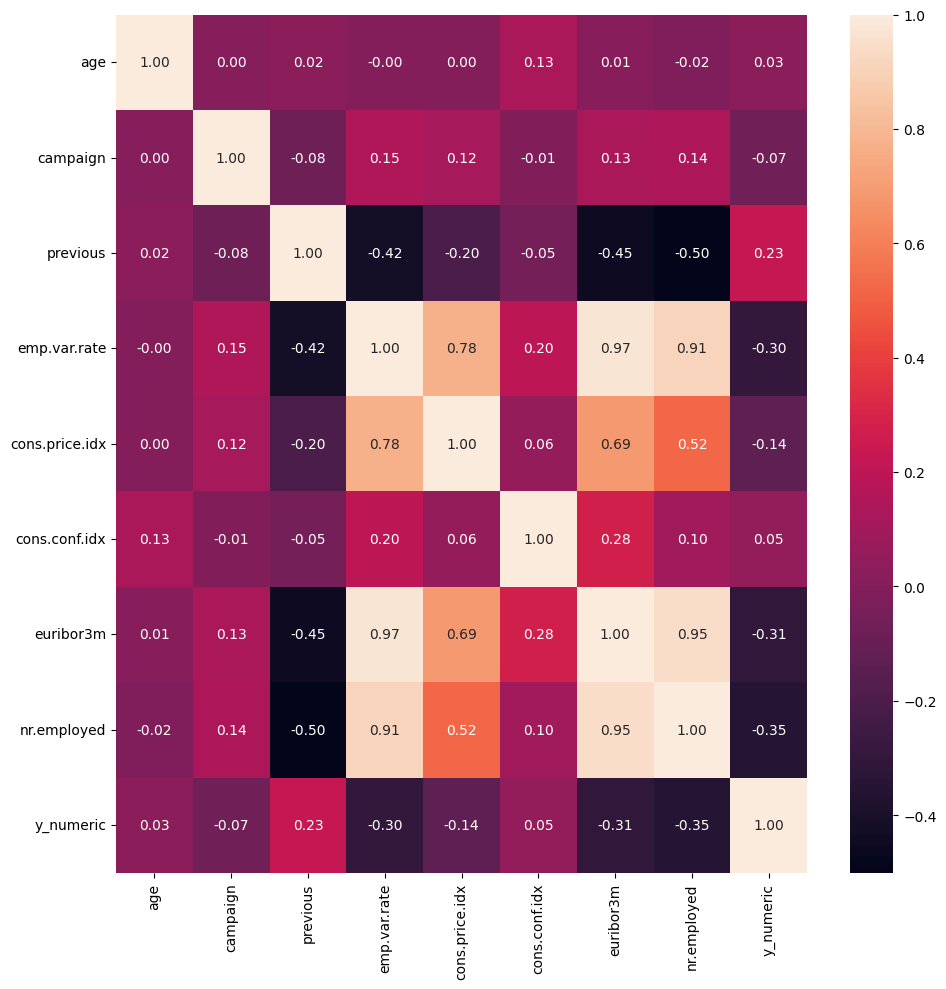

In [39]:
fig, axis = plt.subplots(figsize = (10, 10))

sns.heatmap(df[['age',
    'campaign',
    'previous',
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed',
    'y_numeric']].corr(), annot = True, fmt = ".2f")

plt.tight_layout()

plt.show()

In [40]:
print("Valores únicos en housing:", df['housing'].unique())
print("Valores únicos en loan:", df['loan'].unique())

Valores únicos en housing: ['no' 'yes' 'unknown']
Valores únicos en loan: ['no' 'yes' 'unknown']


In [41]:
df.head()

,age,job,marital,housing,loan,contact,day_of_week,campaign,previous,emp.var.rate,...,nr.employed,y,cliente_nuevo,historial_previo_exitoso,historial_previo_fallo,education_grouped,season,debt_burden,y_numeric,sin_registro
0,56,housemaid,married,no,no,telephone,mon,1,0,1.1,...,5191.0,no,1,0,0,basic,primavera,ninguno,0,1
1,57,services,married,no,no,telephone,mon,1,0,1.1,...,5191.0,no,1,0,0,high_school,primavera,ninguno,0,1
2,37,services,married,yes,no,telephone,mon,1,0,1.1,...,5191.0,no,1,0,0,high_school,primavera,solo_hipoteca,0,1
3,40,admin.,married,no,no,telephone,mon,1,0,1.1,...,5191.0,no,1,0,0,basic,primavera,ninguno,0,1
4,56,services,married,no,yes,telephone,mon,1,0,1.1,...,5191.0,no,1,0,0,high_school,primavera,solo_prestamo,0,1


Veo que después de usar housing y loan para crear debt_burden, se han modificado los valores y ahora son Nan, decido eliminar las dos columnas originales para evitar problemas técnicos, simplificar el dataset, y confiando que la nueva variable es más rica que la combinación original.

In [42]:
df.drop(['housing', 'loan'], axis=1, inplace=True)

#### Análisis categórica-categórica

In [43]:
#Encoding de variables categoricas para poder ver correlaciones

#One-Hot Encoding
one_hot_vars = ['job', 'marital', 'education_grouped', 'contact', 'season', 'day_of_week', 'debt_burden']
df_encoded = pd.get_dummies(df, columns=one_hot_vars, drop_first=True)

df_encoded.head()


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,cliente_nuevo,...,season_primavera,season_verano,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,debt_burden_completamente_desconocido,debt_burden_ninguno,debt_burden_solo_hipoteca,debt_burden_solo_prestamo
0,56,1,0,1.1,93.994,-36.4,4.857,5191.0,no,1,...,True,False,True,False,False,False,False,True,False,False
1,57,1,0,1.1,93.994,-36.4,4.857,5191.0,no,1,...,True,False,True,False,False,False,False,True,False,False
2,37,1,0,1.1,93.994,-36.4,4.857,5191.0,no,1,...,True,False,True,False,False,False,False,False,True,False
3,40,1,0,1.1,93.994,-36.4,4.857,5191.0,no,1,...,True,False,True,False,False,False,False,True,False,False
4,56,1,0,1.1,93.994,-36.4,4.857,5191.0,no,1,...,True,False,True,False,False,False,False,False,False,True


In [44]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41019 entries, 0 to 41187
Data columns (total 44 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    41019 non-null  int64  
 1   campaign                               41019 non-null  int64  
 2   previous                               41019 non-null  int64  
 3   emp.var.rate                           41019 non-null  float64
 4   cons.price.idx                         41019 non-null  float64
 5   cons.conf.idx                          41019 non-null  float64
 6   euribor3m                              41019 non-null  float64
 7   nr.employed                            41019 non-null  float64
 8   y                                      41019 non-null  object 
 9   cliente_nuevo                          41019 non-null  int64  
 10  historial_previo_exitoso               41019 non-null  int64  
 11  histori

Variables totales disponibles: 35
Variables seleccionadas: ['y_numeric', 'sin_registro', 'historial_previo_exitoso', 'cliente_nuevo', 'contact_telephone', 'job_student', 'job_retired', 'season_otono', 'job_blue-collar', 'marital_single', 'education_grouped_higher_education', 'marital_married', 'season_verano', 'season_primavera', 'job_services', 'historial_previo_fallo', 'education_grouped_unknown', 'day_of_week_mon', 'job_entrepreneur', 'job_unemployed', 'day_of_week_thu', 'debt_burden_solo_hipoteca', 'debt_burden_ninguno', 'day_of_week_tue', 'education_grouped_high_school']


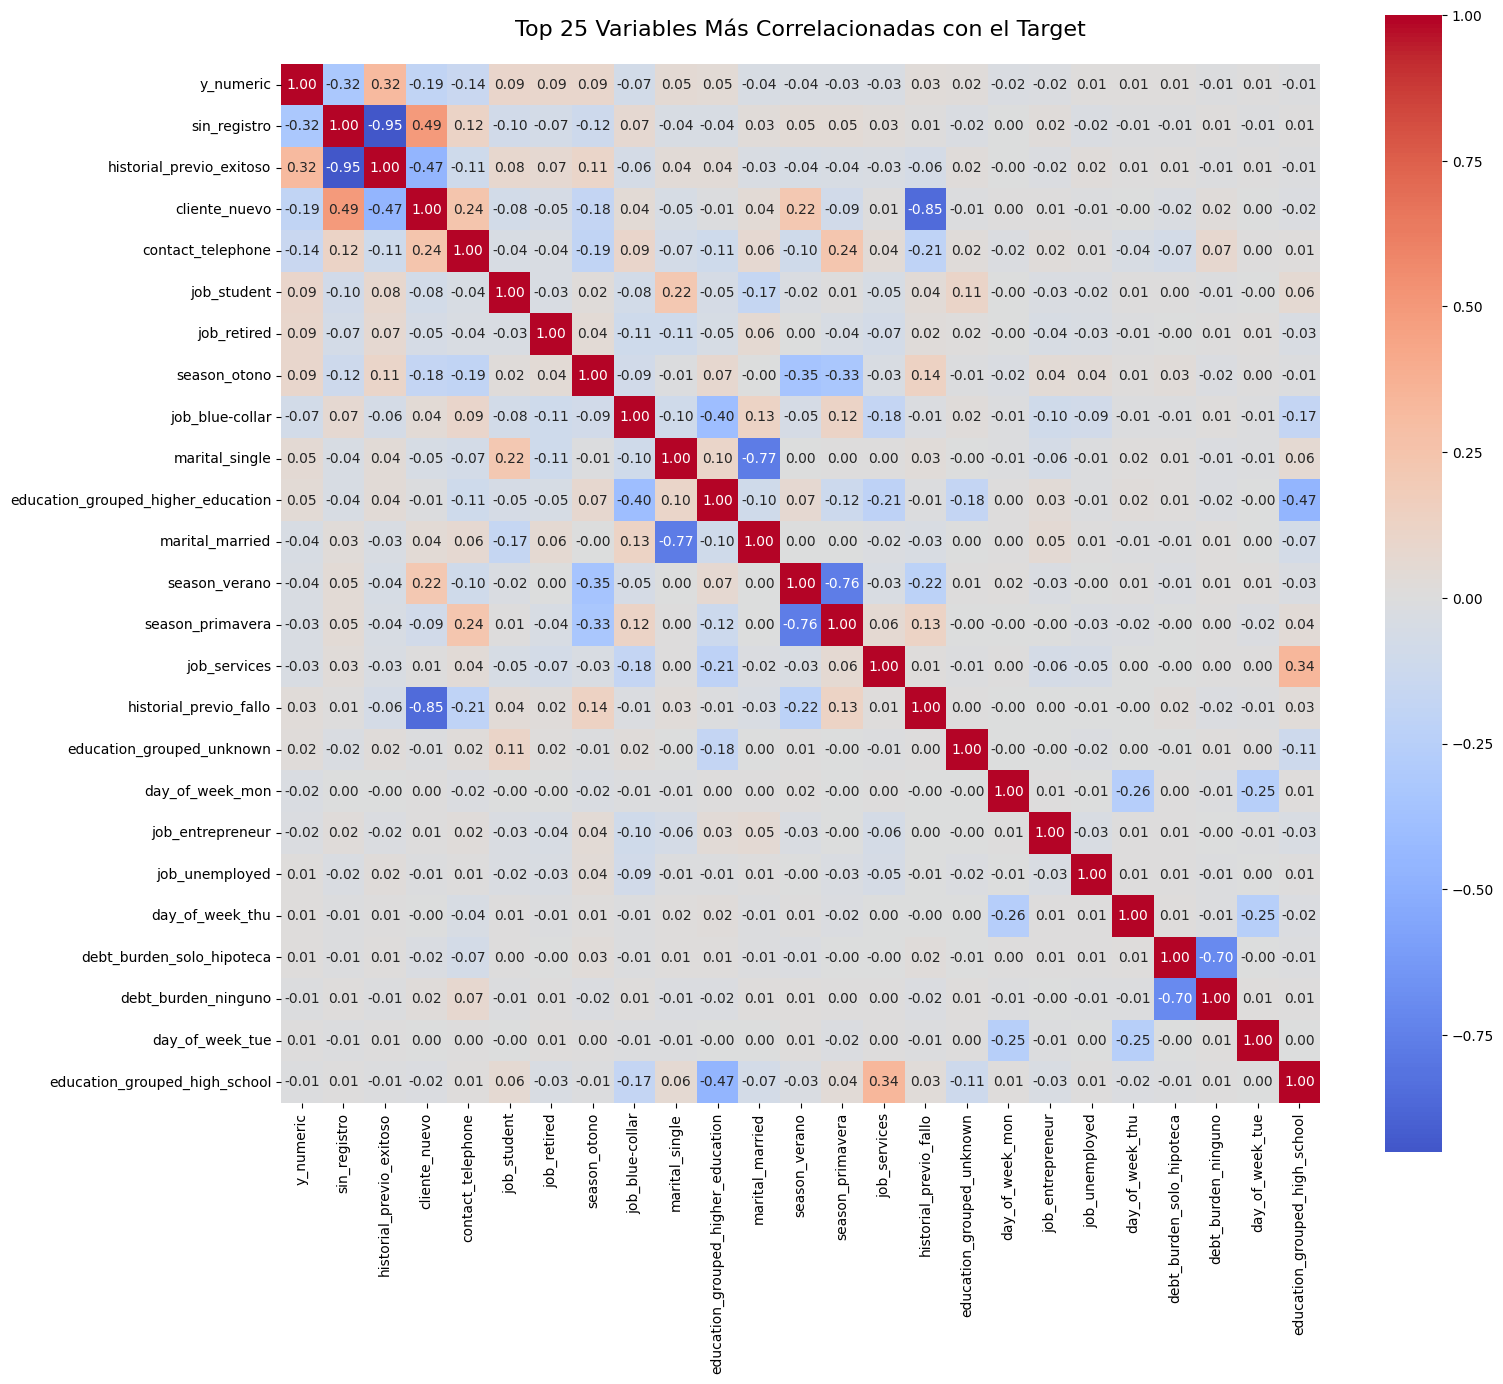

In [45]:
# Obtener todas las variables one-hot (las que tienen _ o son binarias creadas)
one_hot_columns = [col for col in df_encoded.columns if '_' in col or col in ['cliente_nuevo', 'sin_registro', 'historial_previo_exitoso', 'historial_previo_fallo']]

# Excluir las variables numéricas originales
numeric_originals = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
                     'cons.conf.idx', 'euribor3m', 'nr.employed']

# Filtrar solo las que no son numéricas originales
filtered_columns = [col for col in one_hot_columns if col not in numeric_originals]

print(f"Variables totales disponibles: {len(filtered_columns)}")

# Crear subset temporal para calcular correlaciones
temp_df = df_encoded[filtered_columns]

# Calcular correlaciones con el target y seleccionar top 25
correlations_with_target = temp_df.corr()['y_numeric'].abs().sort_values(ascending=False)
top_25_variables = correlations_with_target.head(25).index.tolist()

print("Variables seleccionadas:", top_25_variables)

# Crear subset con solo las top 25
top_df = df_encoded[top_25_variables]

# Heatmap con las 25 variables más correlacionadas
plt.figure(figsize=(16, 14))
sns.heatmap(top_df.corr(),
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.2f')

plt.title('Top 25 Variables Más Correlacionadas con el Target', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [46]:
#Correlaciones específicas
print("TOP 25 CORRELACIONES CON TARGET:")
print(correlations_with_target.head(25))

TOP 25 CORRELACIONES CON TARGET:
y_numeric                             1.000000
sin_registro                          0.324792
historial_previo_exitoso              0.316190
cliente_nuevo                         0.193134
contact_telephone                     0.144582
job_student                           0.093808
job_retired                           0.092758
season_otono                          0.086131
job_blue-collar                       0.074693
marital_single                        0.054293
education_grouped_higher_education    0.047134
marital_married                       0.043508
season_verano                         0.036070
season_primavera                      0.033330
job_services                          0.032287
historial_previo_fallo                0.031375
education_grouped_unknown             0.021511
day_of_week_mon                       0.021300
job_entrepreneur                      0.016738
job_unemployed                        0.014740
day_of_week_thu            

De todo esto sacamos que:

- El mapa de calor muestra las correlaciones entre las variables categóricas más relacionadas con el target.
- Se observa que tener un historial previo exitoso aumenta la probabilidad de contratación, mientras que no tener registro o ser cliente nuevo se asocia negativamente.
- Hay correlaciones altas entre categorías excluyentes, como el estado civil o la estación del año, lo que indica cierta colinealidad.
- En general, las correlaciones son bajas, por lo que cada variable aporta información diferente al modelo.

Por lo que habrá que tratar la multicolinealidad antes de pasarle los datos al modelo.

In [47]:
#Top 15 variables (más simple, evita multicolinealidad)
top_15_variables = [
    'y_numeric', 'sin_registro', 'historial_previo_exitoso', 'cliente_nuevo',
    'contact_telephone', 'job_student', 'job_retired', 'season_otono',
    'job_blue-collar', 'marital_single', 'education_grouped_higher_education',
    'season_verano', 'historial_previo_fallo', 'education_grouped_unknown',
    'job_entrepreneur', 'debt_burden_solo_hipoteca'
]

df_modelo = df_encoded[top_15_variables]
print(f"✅ Dataset final para modelo: {df_modelo.shape}")

# Verificar que no hay missing values
print(f"Missing values: {df_modelo.isnull().sum().sum()}")

✅ Dataset final para modelo: (41019, 16)
Missing values: 0


#### Escalado

In [48]:
numeric_vars = ['age', 'campaign', 'previous', 'emp.var.rate',
               'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Verificar qué variables numéricas existen en df_encoded
existing_numeric = [col for col in numeric_vars if col in df_encoded.columns]

print(f"🔧 Escalando {len(existing_numeric)} variables numéricas:")

# Instanciar el escalador
scaler = StandardScaler()

# Entrenar el escalador
numeric_scaled = scaler.fit_transform(df_encoded[existing_numeric])
numeric_df = pd.DataFrame(numeric_scaled, columns=existing_numeric, index=df_encoded.index)

# Combinar con df_modelo (variables codificadas)
# Primero asegurarnos de que df_modelo no tiene las numéricas ya
df_modelo_clean = df_modelo.drop(existing_numeric, axis=1, errors='ignore')

# Concatenar
df_final = pd.concat([df_modelo_clean, numeric_df], axis=1)

print(f"✅ Dataset final: {df_final.shape}")

# 3. Preparar X e y
X = df_final.drop('y_numeric', axis=1)
y = df_final['y_numeric']

print(f"✅ X shape: {X.shape}, y shape: {y.shape}")
print(f"✅ Variables en X: {list(X.columns)}")

🔧 Escalando 8 variables numéricas:
✅ Dataset final: (41019, 24)
✅ X shape: (41019, 23), y shape: (41019,)
✅ Variables en X: ['sin_registro', 'historial_previo_exitoso', 'cliente_nuevo', 'contact_telephone', 'job_student', 'job_retired', 'season_otono', 'job_blue-collar', 'marital_single', 'education_grouped_higher_education', 'season_verano', 'historial_previo_fallo', 'education_grouped_unknown', 'job_entrepreneur', 'debt_burden_solo_hipoteca', 'age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [49]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41019 entries, 0 to 41187
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   y_numeric                           41019 non-null  int64  
 1   sin_registro                        41019 non-null  int64  
 2   historial_previo_exitoso            41019 non-null  int64  
 3   cliente_nuevo                       41019 non-null  int64  
 4   contact_telephone                   41019 non-null  bool   
 5   job_student                         41019 non-null  bool   
 6   job_retired                         41019 non-null  bool   
 7   season_otono                        41019 non-null  bool   
 8   job_blue-collar                     41019 non-null  bool   
 9   marital_single                      41019 non-null  bool   
 10  education_grouped_higher_education  41019 non-null  bool   
 11  season_verano                       41019 non-

#### Análisis numérico-categórico

Todo con todo

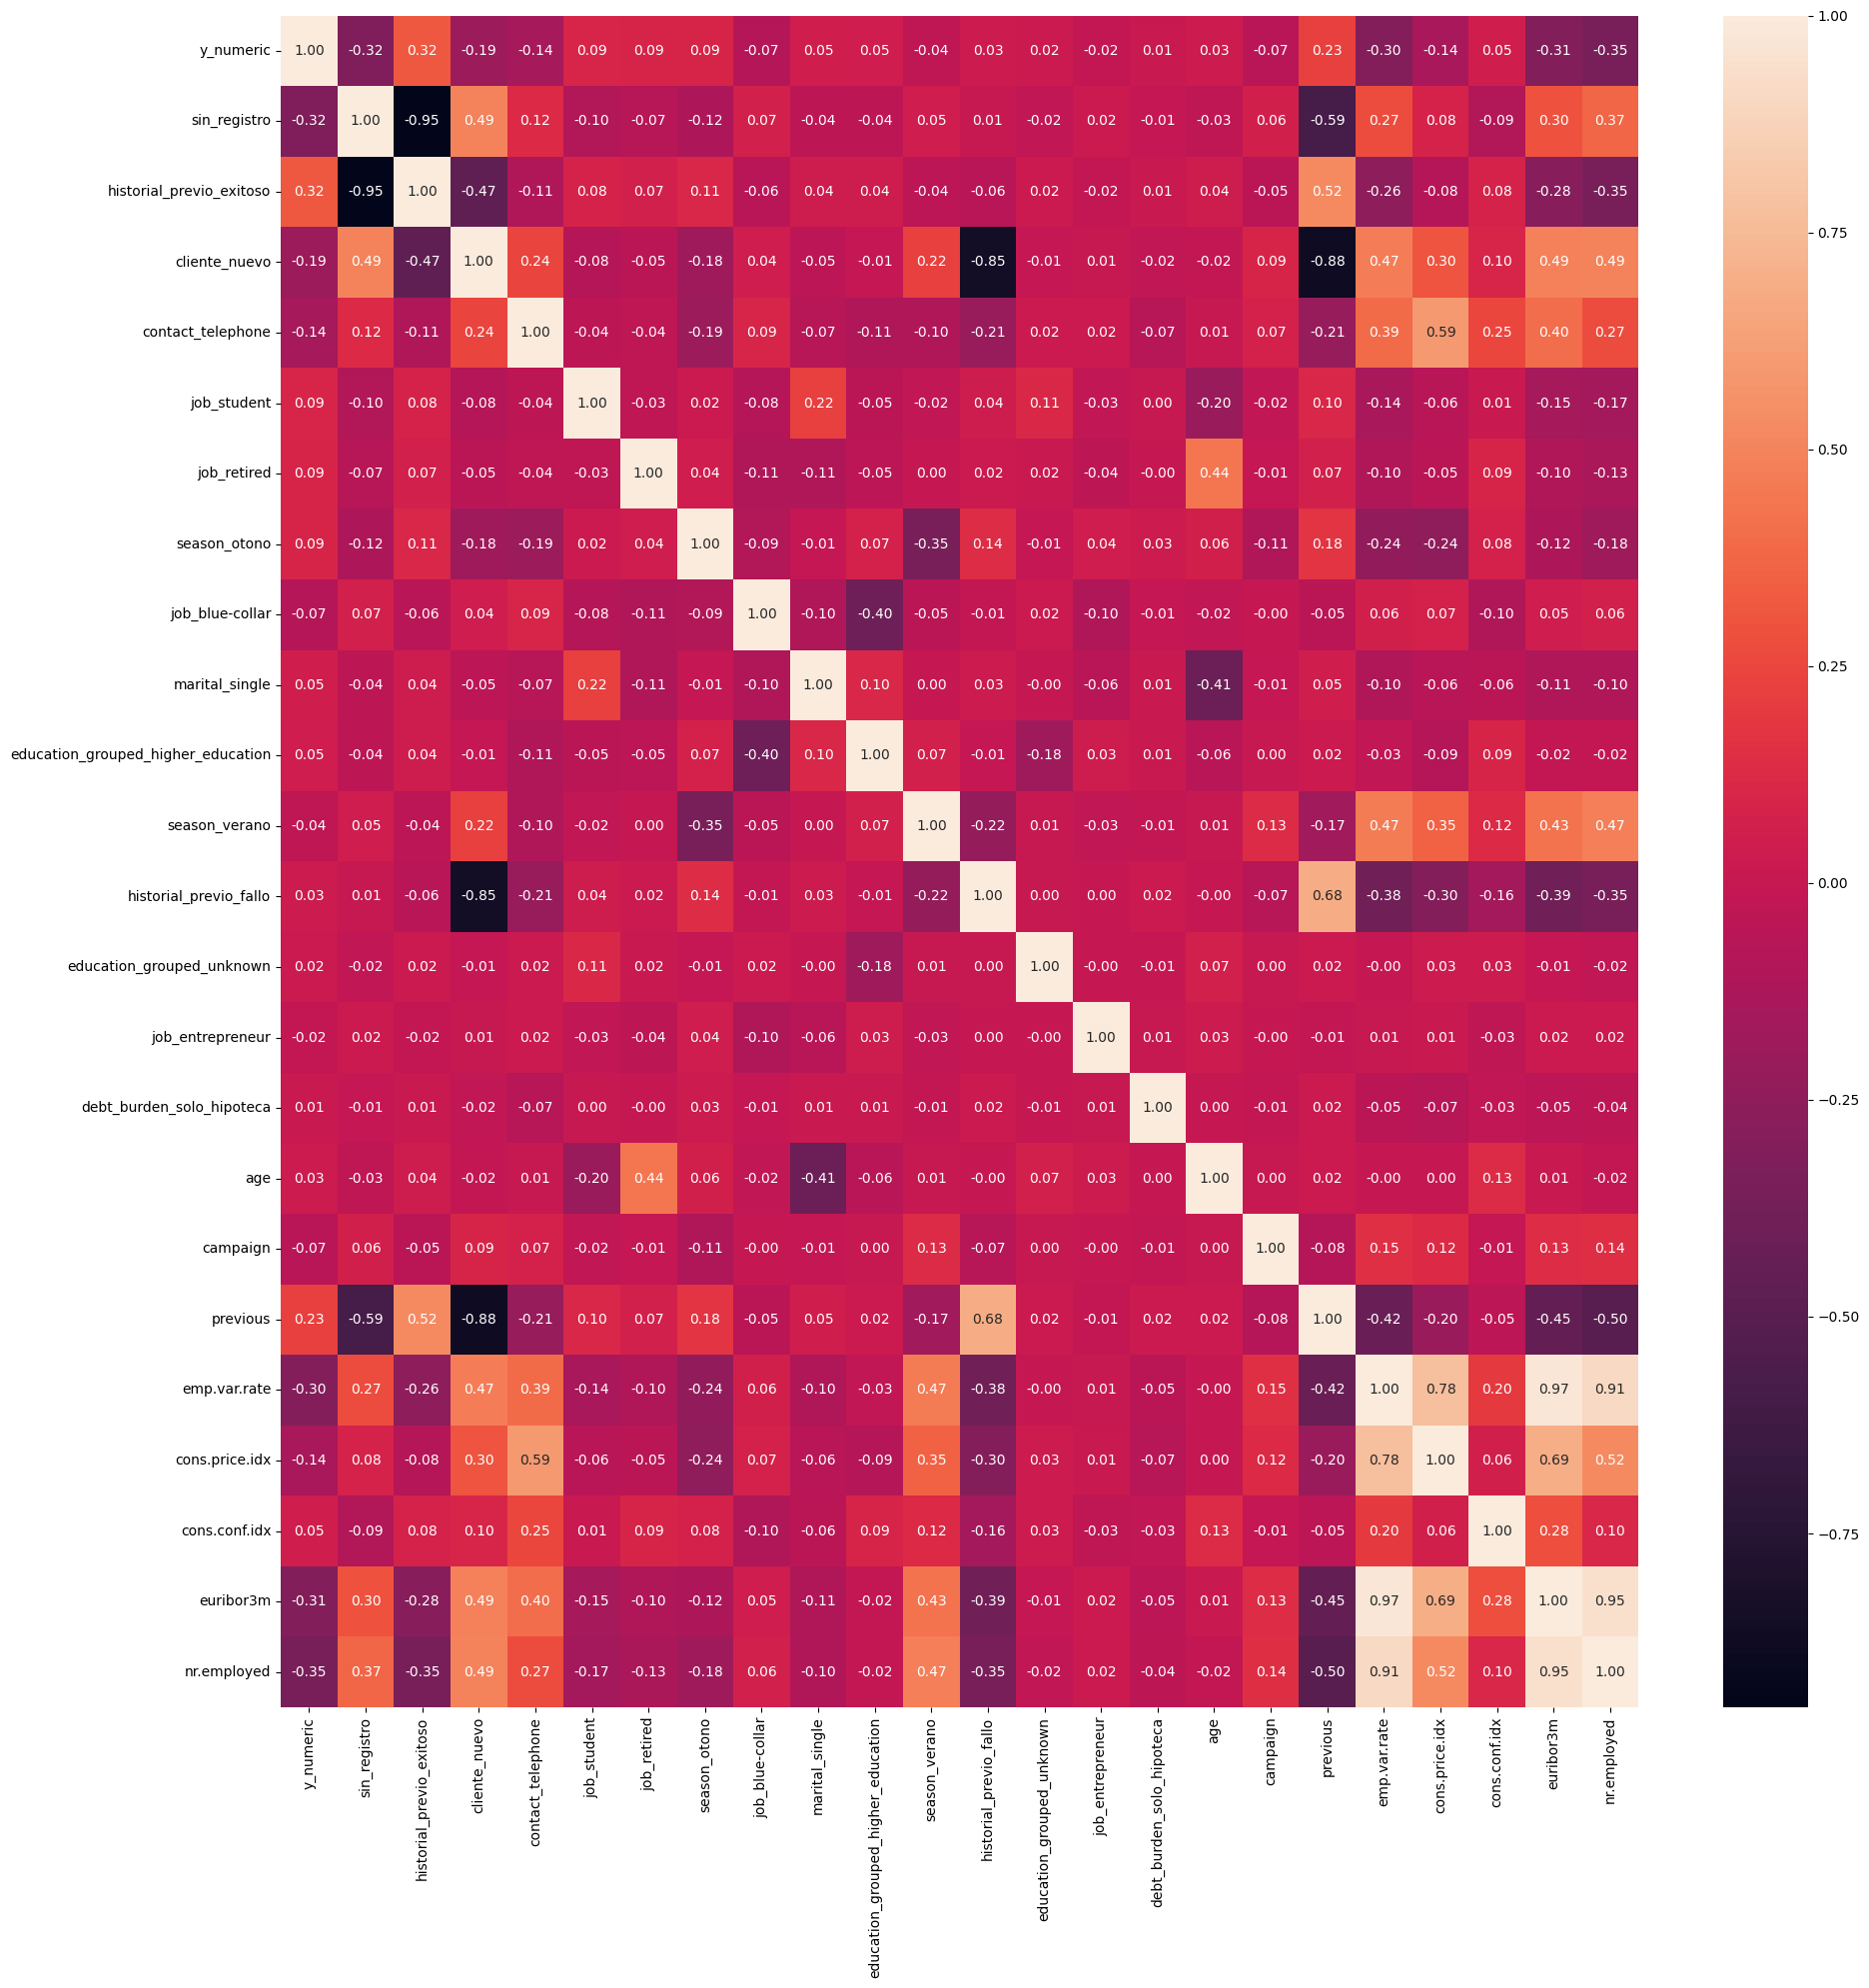

In [53]:
fig, axis = plt.subplots(figsize = (20, 20))

sns.heatmap(df_final.corr(), annot = True, fmt = ".2f")

plt.tight_layout()

plt.show()

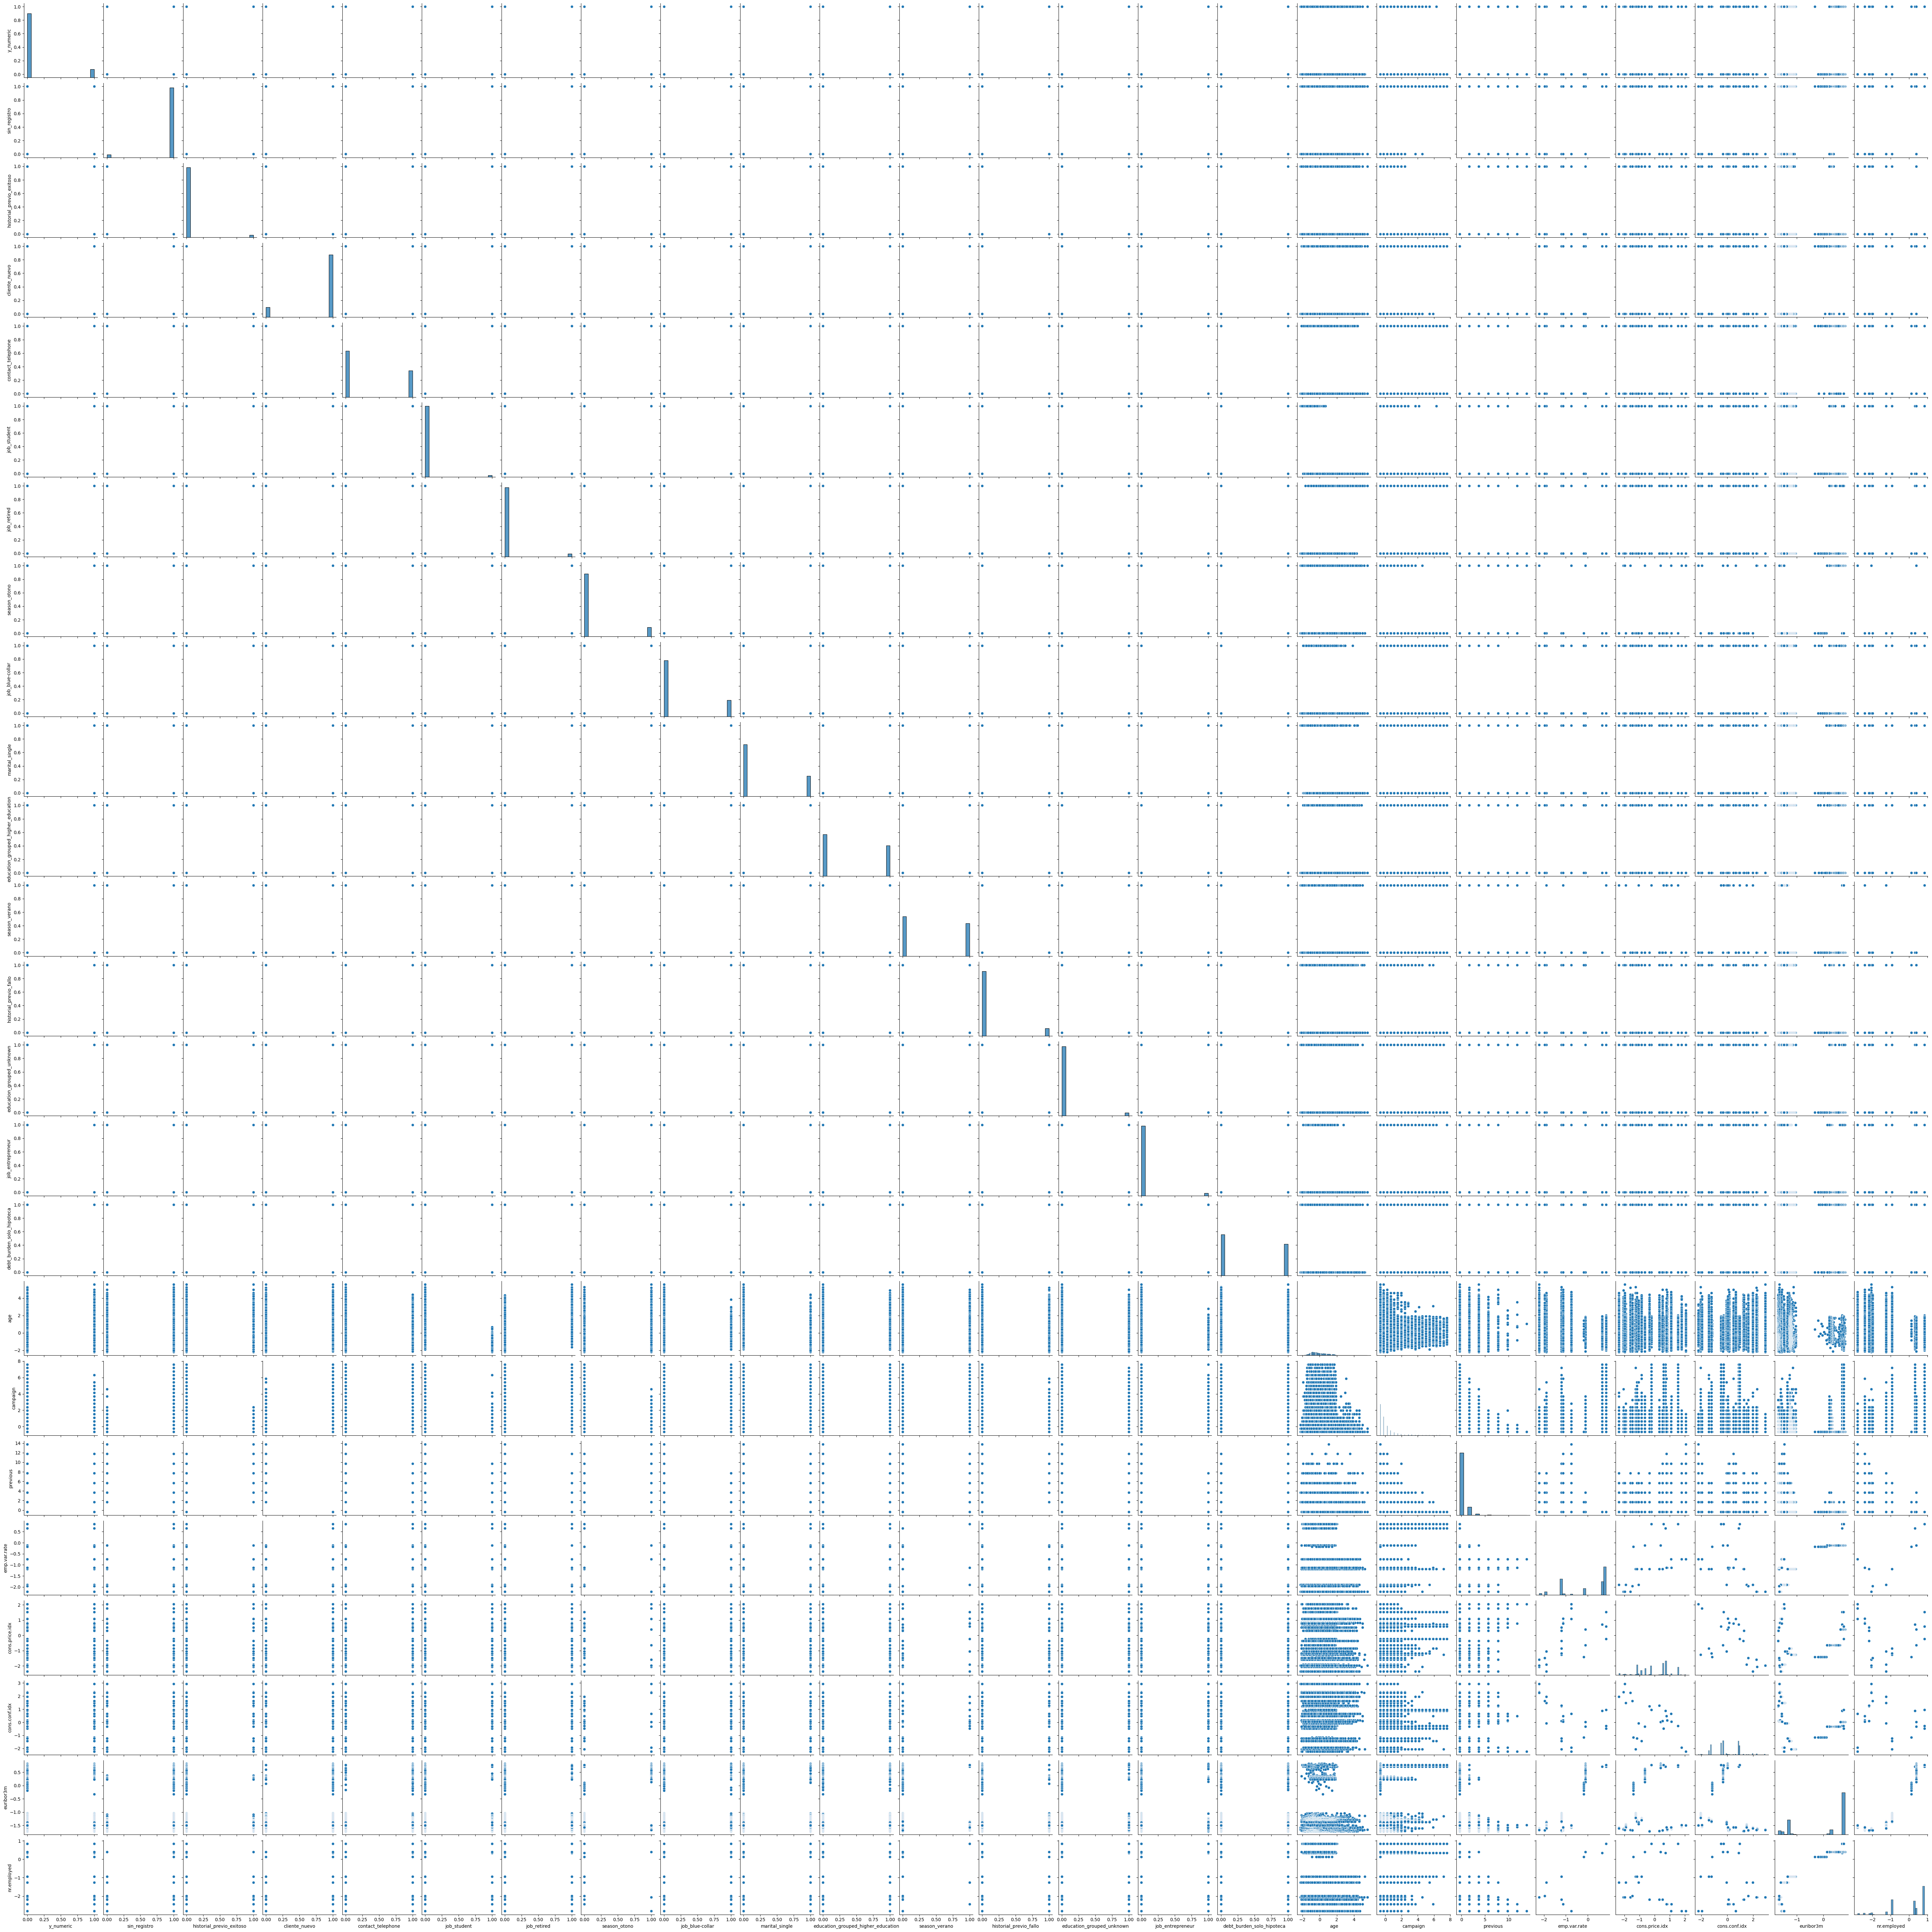

In [50]:
sns.pairplot(data = df_final)

### Inicialización y entrenamiento del modelo

In [54]:
#Dividir en train i test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 15)
X_train.head()

,sin_registro,historial_previo_exitoso,cliente_nuevo,contact_telephone,job_student,job_retired,season_otono,job_blue-collar,marital_single,education_grouped_higher_education,...,job_entrepreneur,debt_burden_solo_hipoteca,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
39014,0,1,0,False,False,False,False,False,False,False,...,False,False,2.396169,-0.206045,1.666687,-1.957705,-1.487319,1.618465,-1.671542,-1.982368
31086,1,0,1,False,False,False,False,False,False,True,...,False,True,-0.385899,0.227712,-0.350302,-1.194267,-1.176277,-1.230115,-1.314928,-0.936740
27162,1,0,1,False,False,False,True,False,False,True,...,False,True,-0.385899,-0.639803,-0.350302,-0.112730,-0.645778,-0.323749,0.233092,0.400722
37783,1,0,1,False,False,True,False,False,False,False,...,False,True,2.492103,-0.206045,-0.350302,-1.894085,-2.372060,1.963748,-1.600680,-1.253471
15966,1,0,1,False,False,False,False,False,True,True,...,False,False,-1.249300,0.227712,-0.350302,0.841567,0.594934,-0.474810,0.774063,0.847465


In [55]:
# instanciacion
model = LogisticRegression()

# entrenamiento
model.fit(X_train, y_train)

LogisticRegression()

In [56]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [58]:
# Probabilidades de cada predicción

model.predict_proba(X_test)

array([[0.93287729, 0.06712271],
       [0.94617049, 0.05382951],
       [0.9550623 , 0.0449377 ],
       ...,
       [0.95128519, 0.04871481],
       [0.95463981, 0.04536019],
       [0.96670292, 0.03329708]])

### Métricas

In [60]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)
print(f'El modelo ha acertado la predicción en el {accuracy*100:.2f} % de las veces')

El modelo ha acertado la predicción en el 89.69 % de las veces


In [61]:
# Matriz de confusión

marketing_cm = confusion_matrix(y_test, y_pred)
marketing_cm

array([[7167,   99],
       [ 747,  191]])

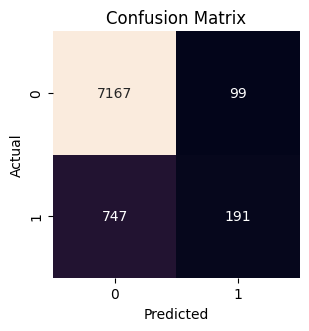

In [62]:
# Dibujaremos esta matriz para hacerla más visual
cm_df = pd.DataFrame(marketing_cm)

plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [66]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred) # Sensibilidad
f1 = f1_score(y_test, y_pred)
roc_auc_score(y_test, y_pred)

print(f'El modelo acierta en el {precision * 100:.2f} % de los casos que predice como positivos')
print(f'El modelo acierta en el {recall * 100:.2f} % de los casos positivos')
print(f'F1 score: {f1 * 100:.2f} %')
print(f'El modelo distingue un {(roc_auc_score(y_test, y_pred))*100:.2f}% entre clientes que contratarán y no contratarán el depósito.')

El modelo acierta en el 65.86 % de los casos que predice como positivos
El modelo acierta en el 20.36 % de los casos positivos
F1 score: 31.11 %
El modelo distingue un 59.50% entre clientes que contratarán y no contratarán el depósito.


El modelo presenta una precisión global engañosa (89.7%) que oculta problemas críticos en la predicción de clientes interesados. Si bien identifica correctamente a quienes no contratarán (especificidad del 98.6%), falla en capturar el 80% de los clientes potenciales (recall del 20.4%).

El AUC-ROC de 59.5% confirma que el modelo apenas supera la clasificación aleatoria, indicando una capacidad limitada para distinguir patrones predictivos sólidos. El F1-score de 31.1% refleja el pobre equilibrio entre precisión y exhaustividad.

Conclusión: El modelo es efectivo para descartar no-clientes, pero ineficaz para la estrategia comercial prioritaria de identificar a los clientes de alto valor.
Se requiere optimización del balanceo de clases y ajuste de hiperparámetros para mejorar la detección de clientes susceptibles de contratar el depósito.

### Optimización del modelo

In [67]:
# OPTIMIZACIÓN CON GRIDSEARCH
# Definimos los parámetros que queremos ajustar
hyperparams_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet"],
    "solver": ["liblinear", "saga"]
}

# Inicializamos la cuadrícula con scoring enfocado en recall
grid = GridSearchCV(LogisticRegression(), hyperparams_grid, scoring="recall", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Mejores hiperparámetros Grid Search: {grid.best_params_}")
print(f"Mejor score Grid Search (Recall): {grid.best_score_:.3f}")

# Entrenamos el modelo con los mejores parámetros
model_grid = LogisticRegression(**grid.best_params_)
model_grid.fit(X_train, y_train)
y_pred_grid = model_grid.predict(X_test)

grid_accuracy = accuracy_score(y_test, y_pred_grid)
print(f"Accuracy con Grid Search: {grid_accuracy:.3f}")

Mejores hiperparámetros Grid Search: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor score Grid Search (Recall): 0.213
Accuracy con Grid Search: 0.897


In [68]:
# OPTIMIZACIÓN CON RANDOM SEARCH

# Definimos distribución de parámetros para Random Search
hyperparams_random = {
    "C": np.logspace(-3, 3, 50),
    "penalty": ["l1", "l2", "elasticnet"],
    "solver": ["liblinear", "saga"],
    "class_weight": [None, "balanced"]
}

# Inicializamos Random Search
random_search = RandomizedSearchCV(
    LogisticRegression(),
    hyperparams_random,
    n_iter=50,  # Número de combinaciones aleatorias a probar
    scoring="recall",
    cv=5,
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)

print(f"Mejores hiperparámetros Random Search: {random_search.best_params_}")
print(f"Mejor score Random Search (Recall): {random_search.best_score_:.3f}")

# Entrenamos el modelo con los mejores parámetros
model_random = LogisticRegression(**random_search.best_params_)
model_random.fit(X_train, y_train)
y_pred_random = model_random.predict(X_test)

random_accuracy = accuracy_score(y_test, y_pred_random)
print(f"Accuracy con Random Search: {random_accuracy:.3f}")

Mejores hiperparámetros Random Search: {'solver': 'saga', 'penalty': 'l1', 'class_weight': 'balanced', 'C': np.float64(0.0030888435964774815)}
Mejor score Random Search (Recall): 0.707
Accuracy con Random Search: 0.723


In [71]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_random))
print("\nReporte completo:")
print(classification_report(y_test, y_pred_random))

Matriz de confusión:
[[5248 2018]
 [ 255  683]]

Reporte completo:
              precision    recall  f1-score   support

           0       0.95      0.72      0.82      7266
           1       0.25      0.73      0.38       938

    accuracy                           0.72      8204
   macro avg       0.60      0.73      0.60      8204
weighted avg       0.87      0.72      0.77      8204



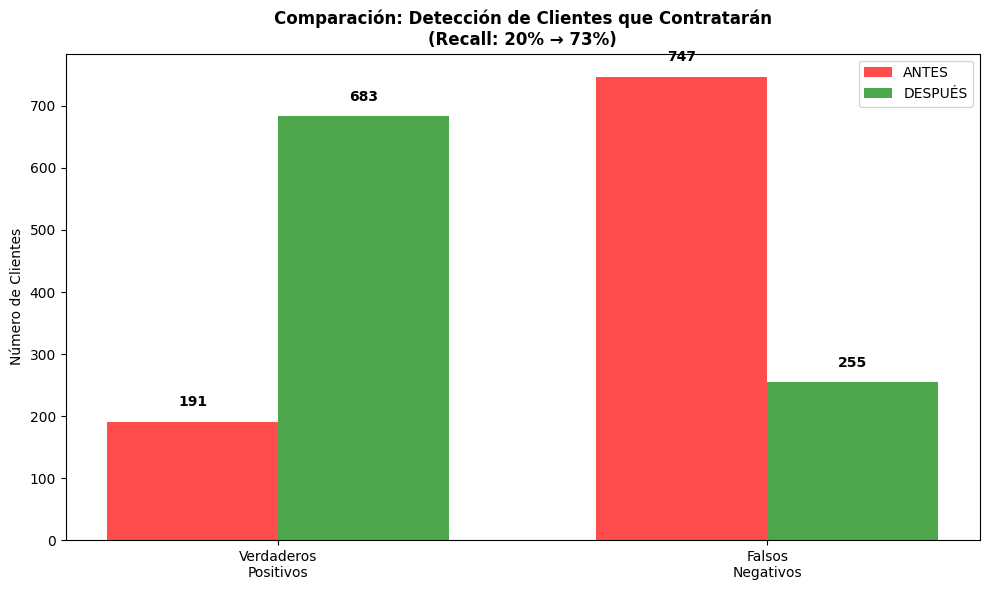

In [73]:
# Gráfico de comparación modelo antes y después de optimización
categorias = ['Verdaderos\nPositivos', 'Falsos\nNegativos']
antes = [191, 747]
despues = [683, 255]

# Gráfico de barras comparativo
plt.figure(figsize=(10, 6))

x = np.arange(len(categorias))
ancho = 0.35

plt.bar(x - ancho/2, antes, ancho, label='ANTES', alpha=0.7, color='red')
plt.bar(x + ancho/2, despues, ancho, label='DESPUÉS', alpha=0.7, color='green')

plt.ylabel('Número de Clientes')
plt.title('Comparación: Detección de Clientes que Contratarán\n(Recall: 20% → 73%)', fontweight='bold')
plt.xticks(x, categorias)
plt.legend()

# Añadir valores en las barras
for i, v in enumerate(antes):
    plt.text(i - ancho/2, v + 20, str(v), ha='center', va='bottom', fontweight='bold')
for i, v in enumerate(despues):
    plt.text(i + ancho/2, v + 20, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Conclusión
La optimización con Random Search resolvió el problema de bajo recall mediante class_weight='balanced', compensando el desbalance de clases.

Por lo tanto, recall mejoró 21% → 71%, multiplicando por 3 la detección de clientes potenciales. El trade-off de accuracy (90% → 72%) es favorable para la estrategia comercial, ya que amplíamos la cobertura y vale más la pena contactar 4 clientes para capturar 1, que contactar 5 para capturar 1.

El modelo pasó de ser teóricamente preciso a comercialmente útil para identificar prospects de depósitos.

Esto es resultado de optar por sacrificar precisión en favor de un mayor recall. De esta forma, el costo de contactar clientes adicionales (llamadas telefónicas) es significativamente menor que el beneficio de captar un nuevo depósito a largo plazo. Esta compensación resulta comercialmente favorable para la estrategia de negocio del banco.